# LLM-Tutor: Offline Evaluation


This notebook analyzes a committed benchmark of 75 mathematical tasks across 15 categories. It compares result-only and structured-reasoning prompt modes for a local Llama 3 8B configuration and a Groq-hosted Llama 3.3 70B configuration.

The notebook is intentionally offline: it reads saved responses and does not call external model APIs.


## Context and methods

The primary outcome is final-answer accuracy. Secondary outcomes are response-format compliance and mean latency. A response is scored using the deterministic evaluator in `src/llm_tutor/evaluation.py`.

### Key assumptions

- The committed CSV contains one response for each task-model-mode combination.
- The hand-authored expected result is the reference target for scoring.
- Latency values are descriptive of the recorded run environment.


In [1]:
from pathlib import Path
import sys
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

REPO_ROOT = next(
    candidate for candidate in [Path.cwd(), *Path.cwd().parents]
    if (candidate / 'data' / 'math_tasks.json').exists()
)
sys.path.insert(0, str(REPO_ROOT / 'src'))

from llm_tutor.evaluation import evaluate_answer, validate_tasks

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_colwidth', 120)


## Data

Validate the task contract before interpreting any benchmark result.

In [2]:
with open(REPO_ROOT / 'data' / 'math_tasks.json', encoding='utf-8') as handle:
    tasks = json.load(handle)

task_contract = validate_tasks(tasks)
task_frame = pd.DataFrame(tasks)
display(pd.DataFrame([task_contract]))
display(task_frame.groupby('category', as_index=False).size().rename(columns={'size': 'task_count'}))


,task_count,category_count
0,75,15


,category,task_count
0,analytic geometry,5
1,arithmetic sequences,5
2,derivatives,5
3,differentiation,5
4,integrals,5
5,limits,5
6,logarithms,5
7,optimization,5
8,percentages,5
9,polynomials,5


In [3]:
raw = pd.read_csv(REPO_ROOT / 'data' / 'tutor_benchmark_raw_results.csv')
summary = pd.read_csv(REPO_ROOT / 'data' / 'tutor_benchmark_summary.csv')
print(f'Raw benchmark rows: {len(raw)}')
display(summary)
assert len(raw) == 75 * 2 * 2
assert raw.groupby(['model', 'variant']).size().eq(75).all()
assert 'audited_score' in raw.columns


Raw benchmark rows: 300


,model,variant,Accuracy %,Lift %,Avg Latency (s),efficiency_score,Compliance %
0,Llama-70B (Groq),cot,97.3,20.0,0.83,1.168819,100.0
1,Llama-70B (Groq),direct,77.3,NaN,0.25,3.143019,100.0
2,Llama-8B (Lokal),cot,72.0,33.3,35.69,0.020175,100.0
3,Llama-8B (Lokal),direct,38.7,NaN,2.83,0.136477,98.7


## Results

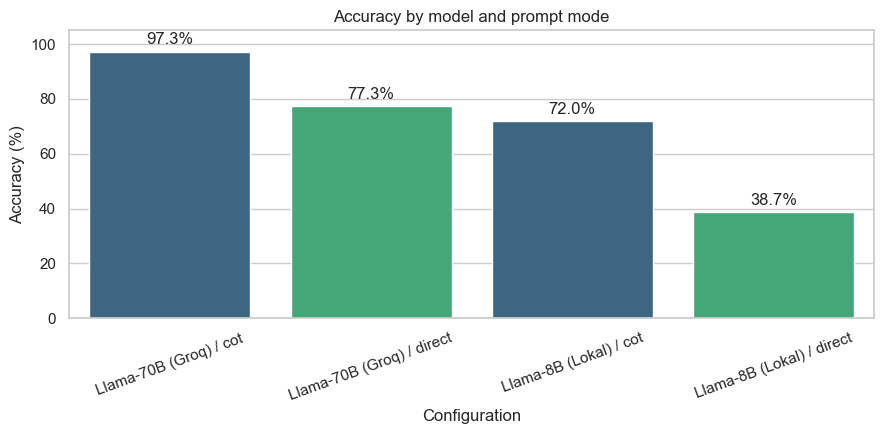

In [4]:
plot_data = summary.copy()
plot_data['label'] = plot_data['model'] + ' / ' + plot_data['variant']
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.barplot(data=plot_data, x='label', y='Accuracy %', hue='variant', legend=False, palette='viridis', ax=ax)
ax.set_title('Accuracy by model and prompt mode')
ax.set_xlabel('Configuration')
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(0, 105)
ax.tick_params(axis='x', rotation=20)
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)
plt.tight_layout()
display(fig)
plt.close(fig)


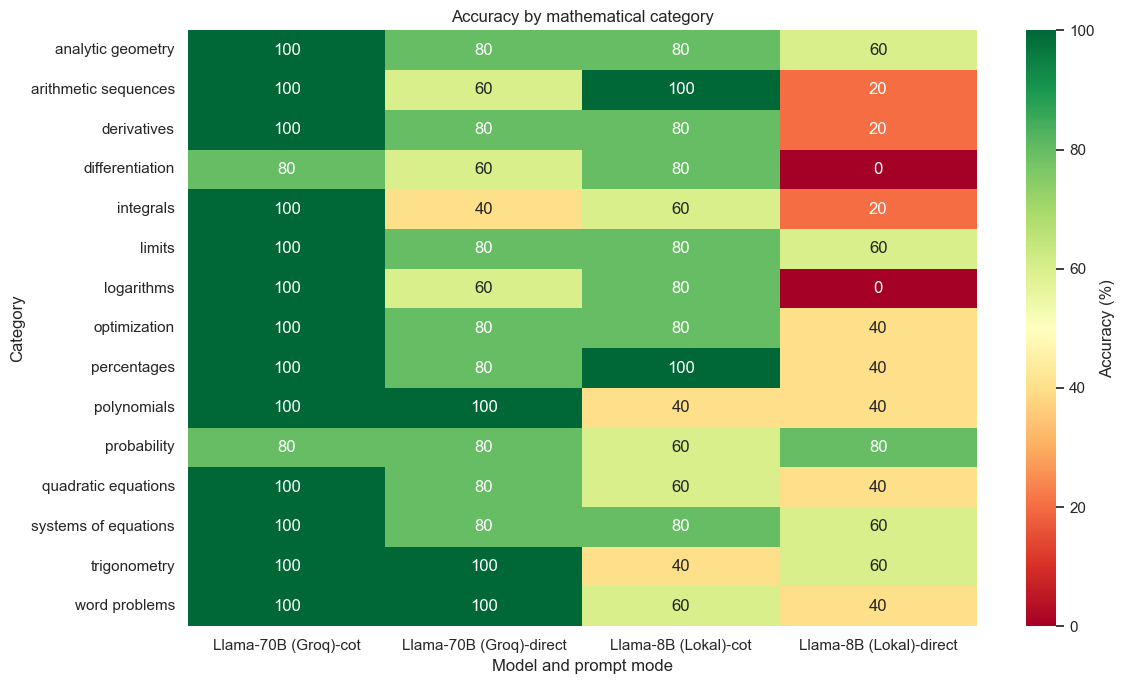

In [5]:
category_accuracy = (
    raw.groupby(['category', 'model', 'variant'], as_index=False)['audited_score']
       .mean()
)
category_accuracy['accuracy_pct'] = category_accuracy['audited_score'] * 100
heatmap_data = category_accuracy.pivot_table(
    index='category', columns=['model', 'variant'], values='accuracy_pct'
)
fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(heatmap_data, annot=True, fmt='.0f', vmin=0, vmax=100,
            cmap='RdYlGn', cbar_kws={'label': 'Accuracy (%)'}, ax=ax)
ax.set_title('Accuracy by mathematical category')
ax.set_xlabel('Model and prompt mode')
ax.set_ylabel('Category')
plt.tight_layout()
display(fig)
plt.close(fig)


## Error inspection

The benchmark preserves raw responses so that aggregate accuracy is not the only evidence available.

In [6]:
errors = raw.loc[raw['audited_score'].eq(0),
                  ['task_id', 'category', 'model', 'variant', 'expected', 'raw_answer']]
print(f'Audited incorrect responses: {len(errors)} of {len(raw)}')
display(errors.head(10))


Audited incorrect responses: 86 of 300


,task_id,category,model,variant,expected,raw_answer
0,1,derivatives,Llama-8B (Lokal),direct,17,[[12]]
2,1,derivatives,Llama-70B (Groq),direct,17,[[31]]
4,2,derivatives,Llama-8B (Lokal),direct,1,[[3]]
8,3,derivatives,Llama-8B (Lokal),direct,-1/2 or -0.5,[[ -2 ]]
9,3,derivatives,Llama-8B (Lokal),cot,-1/2 or -0.5,### ANALYSIS:\n- Function: f(x) = 2/x\n- Point: x = 2\n- Goal: Find the value of the derivative at this point.\n\n##...
16,5,derivatives,Llama-8B (Lokal),direct,1/4 or 0.25,[[1/2]]
24,7,analytic geometry,Llama-8B (Lokal),direct,5,[[3]]
32,9,analytic geometry,Llama-8B (Lokal),direct,11,[[8]]
34,9,analytic geometry,Llama-70B (Groq),direct,11,[[9]]
37,10,analytic geometry,Llama-8B (Lokal),cot,4,ANALYSIS:\n- Equation: $(x-1)^2 + (y+2)^2 = 16$\n- Goal: Find the length of the radius.\n\nREASONING:\n1. The equati...


## Takeaways

- Structured reasoning improved final-answer accuracy in both configurations on this fixed benchmark.
- The local model received the larger accuracy lift, but structured-mode latency increased substantially.
- The hosted 70B configuration produced the best quality-latency balance in the recorded run.